### Approach 2: Pixel-level RGB + Spatial Coordinates

This approach extends pixel-level classification by incorporating spatial
information. Each pixel is represented by its color values along with its
normalized image coordinates (x, y).

By adding spatial priors, the model can learn that certain classes tend to appear
in specific regions of the image, such as the floor appearing more frequently
near the bottom.

**Feature Vector:** (R, G, B, x, y)  
**Sample Unit:** Pixel  
**Strengths:** Encodes spatial context, significantly improves accuracy  
**Limitations:** Still ignores texture and local structure  
**Expected Behavior:** Cleaner segmentation compared to RGB-only classification

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from pycocotools.coco import COCO
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# IMAGE_DIR = "/content/drive/MyDrive/Floor Segmentation.v4i.coco-segmentation/train"
# COCO_JSON = "/content/drive/MyDrive/Floor Segmentation.v4i.coco-segmentation/train/_annotations.coco.json"
IMAGE_DIR = "/content/drive/MyDrive/230077_vivekananda"
COCO_JSON = "/content/drive/MyDrive/230077_vivekananda/vivekananda.json"

coco = COCO(COCO_JSON)

print(f"Total images: {len(coco.imgs)}")
print(f"Total annotations: {len(coco.getAnnIds())}")

# Floor category IDs (adjust if needed)
FLOOR_CAT_IDS = [0, 1]

loading annotations into memory...
Done (t=1.25s)
creating index...
index created!
Total images: 10
Total annotations: 10


In [3]:
img_ids = list(coco.imgs.keys())
print(f"Images to process: {len(img_ids)}")

Images to process: 10


In [4]:
X = []
y = []

PIXELS_PER_IMAGE = 300  # keep this small

print("Extracting pixel-level RGB + (x, y) samples...")

for i, img_id in enumerate(img_ids):
    img_info = coco.loadImgs(img_id)[0]
    img_path = os.path.join(IMAGE_DIR, img_info["file_name"])
    img = cv2.imread(img_path)

    if img is None:
        continue

    h, w = img.shape[:2]

    # Build floor mask
    floor_mask = np.zeros((h, w), dtype=np.uint8)
    ann_ids = coco.getAnnIds(imgIds=img_id)
    anns = coco.loadAnns(ann_ids)

    for ann in anns:
        if ann["category_id"] in FLOOR_CAT_IDS:
            floor_mask |= coco.annToMask(ann)

    for _ in range(PIXELS_PER_IMAGE):
        py = np.random.randint(0, h)
        px = np.random.randint(0, w)

        R, G, B = img[py, px]

        # Normalized coordinates
        x_norm = px / w
        y_norm = py / h

        X.append([R, G, B, x_norm, y_norm])
        y.append(1 if floor_mask[py, px] else 0)

    if (i + 1) % 50 == 0:
        print(f"Processed {i+1}/{len(img_ids)} images")

X = np.array(X)
y = np.array(y)

print(f"Total samples: {len(X)}")
print(f"Floor pixels: {np.sum(y == 1)}")
print(f"Non-floor pixels: {np.sum(y == 0)}")

Extracting pixel-level RGB + (x, y) samples...
Total samples: 3000
Floor pixels: 1394
Non-floor pixels: 1606


In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 2400
Test size: 600


In [7]:
svm = SVC(
    kernel="linear",
    C=1,
    random_state=42
)

svm.fit(X_train, y_train)

SVC(C=1, kernel='linear', random_state=42)

In [8]:
y_pred = svm.predict(X_test)

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

print("Train Accuracy:", svm.score(X_train, y_train))
print("Test Accuracy:", svm.score(X_test, y_test))

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.86      0.87       321
           1       0.84      0.87      0.85       279

    accuracy                           0.86       600
   macro avg       0.86      0.86      0.86       600
weighted avg       0.86      0.86      0.86       600

Train Accuracy: 0.8645833333333334
Test Accuracy: 0.8616666666666667


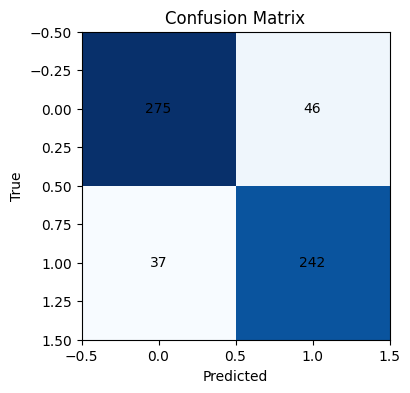

In [9]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4,4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

In [10]:
def predict_floor_pixelwise_xy(img_path, svm, scaler):
    img = cv2.imread(img_path)
    h, w = img.shape[:2]

    features = []
    for py in range(h):
        for px in range(w):
            R, G, B = img[py, px]
            features.append([R, G, B, px / w, py / h])

    features = np.array(features)
    features_scaled = scaler.transform(features)

    preds = svm.predict(features_scaled)
    mask = preds.reshape(h, w)

    return img, mask

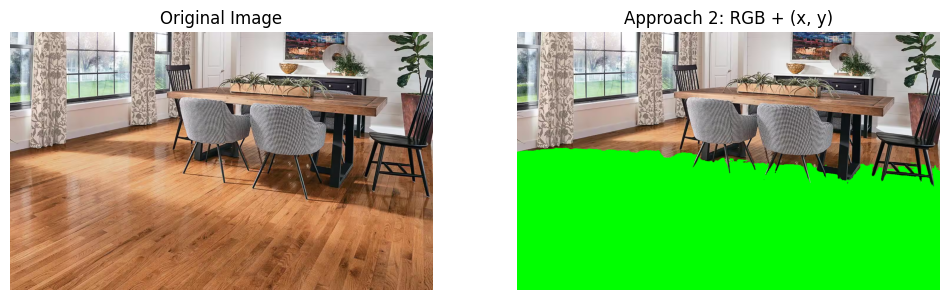

In [11]:
test_img_path = "/content/floor-1.avif"  # replace if needed

img, mask = predict_floor_pixelwise_xy(test_img_path, svm, scaler)

overlay = img.copy()
overlay[mask == 1] = [0, 255, 0]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title("Approach 2: RGB + (x, y)")
plt.axis("off")

plt.show()

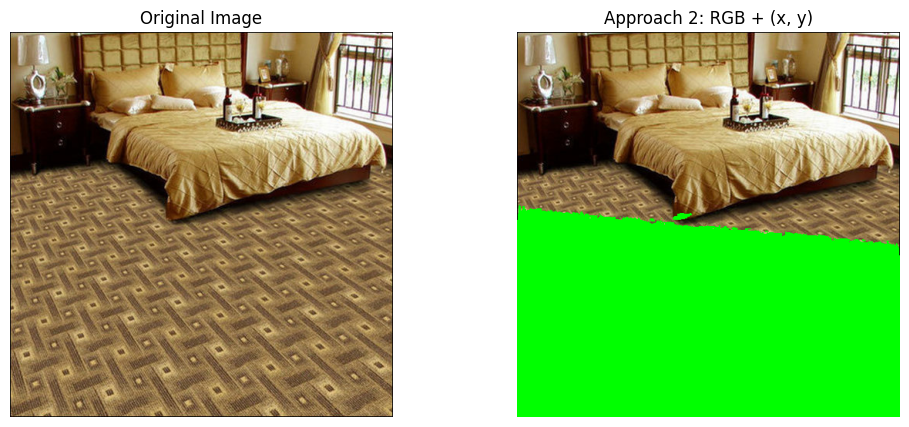

In [12]:
test_img_path = "/content/floor-10.jpg"  # replace if needed

img, mask = predict_floor_pixelwise_xy(test_img_path, svm, scaler)

overlay = img.copy()
overlay[mask == 1] = [0, 255, 0]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title("Approach 2: RGB + (x, y)")
plt.axis("off")

plt.show()